# Task 10 — Camera Calibration and Lens Undistortion

This printed target has **9×6 squares**, meaning it contains **8×5 internal corners**. Run every cell from top to bottom.

In [13]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

CALIB_DIR = Path('calib_images')
SCENE_PATH = Path('ordinary_scene.jpg')  # Add this photo later
SQUARES = (9, 6)
INNER_CORNERS = (SQUARES[0] - 1, SQUARES[1] - 1)  # (8, 5)
MIN_RECOMMENDED_VIEWS = 12
CRITERIA = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 1e-4)

print(f'Searching for {INNER_CORNERS[0]}×{INNER_CORNERS[1]} internal corners.')

Searching for 8×5 internal corners.


In [14]:
# Detect and refine the checkerboard corners.
def make_portrait(image):
    # OpenCV ignores phone EXIF orientation; normalize landscape captures.
    return cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE) if image.shape[1] > image.shape[0] else image

def find_corners(gray):
    flags = (cv2.CALIB_CB_ADAPTIVE_THRESH | cv2.CALIB_CB_NORMALIZE_IMAGE |
             cv2.CALIB_CB_FILTER_QUADS)
    found, corners = cv2.findChessboardCorners(gray, INNER_CORNERS, flags)
    method = 'findChessboardCorners'
    if not found:
        # Robust fallback for a few strongly tilted but still usable photos.
        found, corners = cv2.findChessboardCornersSB(
            gray, INNER_CORNERS,
            cv2.CALIB_CB_NORMALIZE_IMAGE | cv2.CALIB_CB_EXHAUSTIVE)
        method = 'findChessboardCornersSB'
    if found:
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), CRITERIA)
    return found, corners, method

image_paths = sorted({*CALIB_DIR.glob('*.jpg'), *CALIB_DIR.glob('*.JPG')})
object_template = np.zeros((np.prod(INNER_CORNERS), 3), np.float32)
object_template[:, :2] = np.mgrid[0:INNER_CORNERS[0], 0:INNER_CORNERS[1]].T.reshape(-1, 2)
object_points, image_points, accepted, discarded = [], [], [], []
reference_size = None

for path in image_paths:
    image = cv2.imread(str(path))
    if image is None:
        discarded.append((path.name, 'unreadable file'))
        continue
    image = make_portrait(image)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image_size = gray.shape[::-1]
    if reference_size is None:
        reference_size = image_size
    if image_size != reference_size:
        discarded.append((path.name, f'different image size {image_size}; expected {reference_size}'))
        continue
    found, corners, method = find_corners(gray)
    if not found:
        discarded.append((path.name, 'full 8×5 grid not found: likely blur, glare, crop, or extreme tilt'))
        continue
    object_points.append(object_template.copy())
    image_points.append(corners)
    accepted.append((path.name, method))

print(f'Images found: {len(image_paths)}')
print(f'Accepted: {len(accepted)}')
for name, method in accepted:
    print(f'  [USED] {name}: {method} + cornerSubPix')
print(f'Discarded: {len(discarded)}')
for name, reason in discarded:
    print(f'  [DISCARDED] {name}: {reason}')
if len(accepted) < MIN_RECOMMENDED_VIEWS:
    print(f'\nRecommendation: retake at least {MIN_RECOMMENDED_VIEWS - len(accepted)} more usable views before submitting.')

Images found: 15
Accepted: 7
  [USED] img1.jpg: findChessboardCorners + cornerSubPix
  [USED] img2.jpg: findChessboardCorners + cornerSubPix
  [USED] img3.jpg: findChessboardCorners + cornerSubPix
  [USED] img4.jpg: findChessboardCornersSB + cornerSubPix
  [USED] img5.jpg: findChessboardCornersSB + cornerSubPix
  [USED] img8.jpg: findChessboardCornersSB + cornerSubPix
  [USED] img9.jpg: findChessboardCorners + cornerSubPix
Discarded: 8
  [DISCARDED] img10.jpg: full 8×5 grid not found: likely blur, glare, crop, or extreme tilt
  [DISCARDED] img11.jpg: full 8×5 grid not found: likely blur, glare, crop, or extreme tilt
  [DISCARDED] img12.jpg: full 8×5 grid not found: likely blur, glare, crop, or extreme tilt
  [DISCARDED] img13.jpg: full 8×5 grid not found: likely blur, glare, crop, or extreme tilt
  [DISCARDED] img14.jpg: full 8×5 grid not found: likely blur, glare, crop, or extreme tilt
  [DISCARDED] img15.jpg: different image size (2296, 4080); expected (3060, 4080)
  [DISCARDED] img6

In [10]:
# Calibrate the camera and report the assignment values.
if len(accepted) < 3:
    raise RuntimeError('Need at least 3 valid checkerboard images to calibrate.')

rms, camera_matrix, distortion, rvecs, tvecs = cv2.calibrateCamera(
    object_points, image_points, reference_size, None, None)

residuals = []
for obj, observed, rvec, tvec in zip(object_points, image_points, rvecs, tvecs):
    projected, _ = cv2.projectPoints(obj, rvec, tvec, camera_matrix, distortion)
    residuals.extend(np.linalg.norm(observed.reshape(-1, 2) - projected.reshape(-1, 2), axis=1))
mean_reprojection_error = float(np.mean(residuals))

fx, fy = camera_matrix[0, 0], camera_matrix[1, 1]
cx, cy = camera_matrix[0, 2], camera_matrix[1, 2]
print('--- CALIBRATION RESULTS ---')
print(f'fx = {fx:.2f} px, fy = {fy:.2f} px')
print(f'cx = {cx:.2f} px, cy = {cy:.2f} px')
print(f'OpenCV RMS reprojection error = {rms:.4f} px')
print(f'Mean point reprojection error = {mean_reprojection_error:.4f} px')
print('Distortion coefficients:', distortion.ravel())
np.savez('camera_calibration.npz', camera_matrix=camera_matrix, distortion=distortion)

--- CALIBRATION RESULTS ---
fx = 3236.20 px, fy = 3233.42 px
cx = 1566.03 px, cy = 1940.66 px
OpenCV RMS reprojection error = 7.4147 px
Mean point reprojection error = 5.8990 px
Distortion coefficients: [ 4.87841519e-01 -2.37984478e+00 -1.36986746e-02 -1.80809652e-03
  4.04020693e+00]


Scaled camera matrix from (3060, 4080) to (1200, 1600).


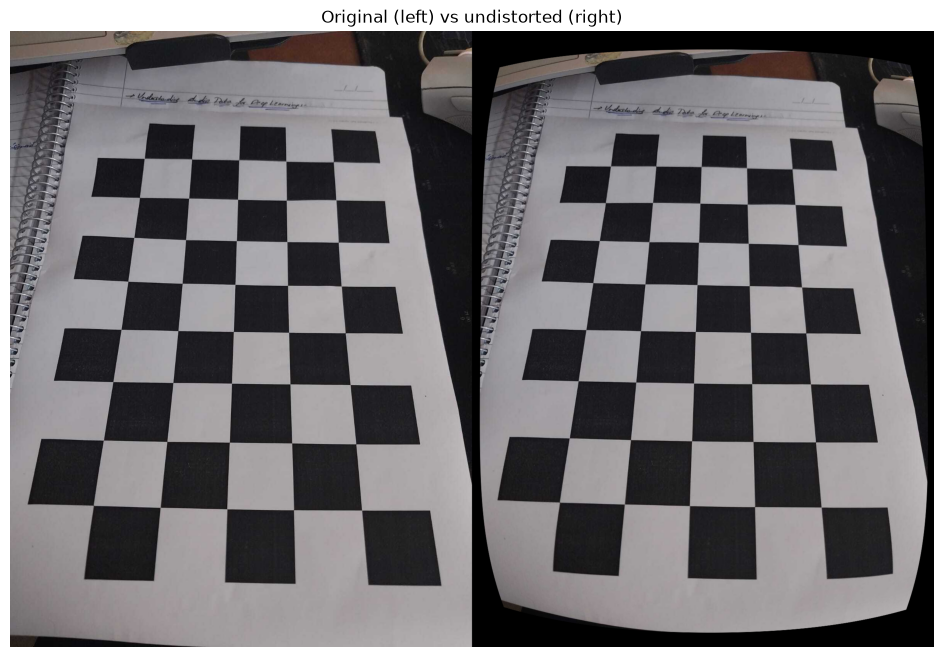

Saved undistortion_before_after.jpg


In [15]:
# Undistort an ordinary scene with long straight lines near the image edges.
if not SCENE_PATH.exists():
    print(f'Add your scene photo as {SCENE_PATH.name}, then rerun this cell.')
else:
    scene = cv2.imread(str(SCENE_PATH))
    if scene is None:
        raise ValueError(f'Could not read {SCENE_PATH}')
    scene = make_portrait(scene)
    scene_size = scene.shape[1::-1]
    scale_x = scene_size[0] / reference_size[0]
    scale_y = scene_size[1] / reference_size[1]
    if not np.isclose(scale_x, scale_y, rtol=0.01):
        raise ValueError(
            f'Scene aspect ratio {scene_size[0] / scene_size[1]:.3f} differs from calibration aspect ratio '
            f'{reference_size[0] / reference_size[1]:.3f}. Retake it using the same camera aspect ratio.')
    scaled_camera_matrix = camera_matrix.copy()
    scaled_camera_matrix[0, 0] *= scale_x  # fx
    scaled_camera_matrix[1, 1] *= scale_y  # fy
    scaled_camera_matrix[0, 2] *= scale_x  # cx
    scaled_camera_matrix[1, 2] *= scale_y  # cy
    undistorted = cv2.undistort(scene, scaled_camera_matrix, distortion)
    print(f'Scaled camera matrix from {reference_size} to {scene_size}.')
    comparison = np.hstack([scene, undistorted])
    cv2.imwrite('undistortion_before_after.jpg', comparison)
    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(comparison, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Original (left) vs undistorted (right)')
    plt.show()
    print('Saved undistortion_before_after.jpg')

## Write-up

Use the printed accepted/discarded counts and reasons in your write-up. Report the four camera-matrix values and mean reprojection error from the calibration cell. Before submitting, use 12–15 sharp, varied, compatible-resolution calibration images and show the before/after undistortion comparison.